# Solution of the truss problem

First of all the data needs to be declared. These include

- the number of nodes
- the number of elements
- the coordinates of the nodes
- the connectivity of the members
- the element stiffness
- the nodal forces vector
- the boundary conditions

To have consistent units the Young modulus is expressed in [kN/m^2], the area in [m^2] and the length in [m]. This means that the external forces need to be expressed in [kN]. 

The obtained displacement will be expressed in [m] and the reaction forces are also expressed in [kN].

The following code declares the data for the problem



In [5]:
import numpy as np

A = 4000 * 1e-6 # m^2
E = 70 * 1e6 # kPa

EA = A * E

L_1 = 6 # m
L_2 = 4 # m
H = 8   # m

# The nodes are numbered from the bottom to the top, from the left to the right

node_1 = np.array([0, 0])
node_2 = np.array([L_1 + L_2, 0])
node_3 = np.array([0, H])
node_4 = np.array([L_1, H])

coordinates = np.vstack((node_1, node_2, node_3, node_4))

connectivity_table = np.array([[1, 3],
                               [3, 4],
                               [1, 4],
                               [2, 3],
                               [2, 4]]) - 1 # -1 because of python convention

n_nodes = coordinates.shape[0]
n_elements = connectivity_table.shape[0]

n_dofs = n_nodes * 2

# Dictionary containing information on the force value at solicitated nodes
dict_forces_1 = {3: np.array([0, - 400]),
               4: np.array([800, - 400])}

f = np.zeros(n_dofs)

for node, force_node in dict_forces_1.items():
    node_id = node - 1
    f[2*node_id:2*node_id+2] = force_node


# Node 1, 2 fixes the x, y displacement. Node 3 fixes the x displacement
dofs_bcs = [0, 1, 2, 3, 4]

Then the second part consists in assembling the stiffness matrix. First of all we verify that the mesh is correct by plotting the different elements    

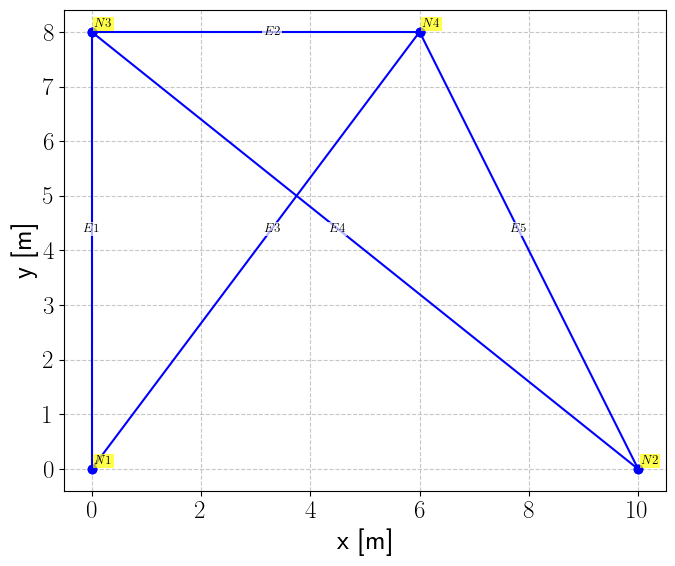

In [6]:
from matplotlib import pyplot as plt
from src.postprocessing.plot_mesh import plot_truss_structure_2d

ax = plot_truss_structure_2d(coordinates, connectivity_table,
        show_element_labels=True,
        show_node_labels=True,
        color='blue',
        linestyle='o-',
        xlabel='x [m]',
        ylabel='y [m]',)

Once the mesh has been verified, we can proceed to the construction of the stiffness matrix

In [7]:
from src.fem.assemble_matrices import assemble_stiffness_truss_2d
from src.linear_algebra.solve_system import solve_system_homogeneous_bcs

K = assemble_stiffness_truss_2d(coordinates, connectivity_table, EA)
q_all, reactions = solve_system_homogeneous_bcs(K, f, dofs_bcs)

q_all_mm = [round(v, 4) for v in 1e3*q_all]
print(f"Displacement at these nodes [mm]:\n {q_all_mm}\n")
print(f"Reactions at bcs in [kN]:\n {reactions}\n")

Displacement at these nodes [mm]:
 [0.0, 0.0, 0.0, 0.0, 0.0, -9.1886, 12.8365, -9.5844]

Reactions at bcs in [kN]:
 [  -0.57760745  320.82925204 -298.3858275   479.17074796 -501.03656505]



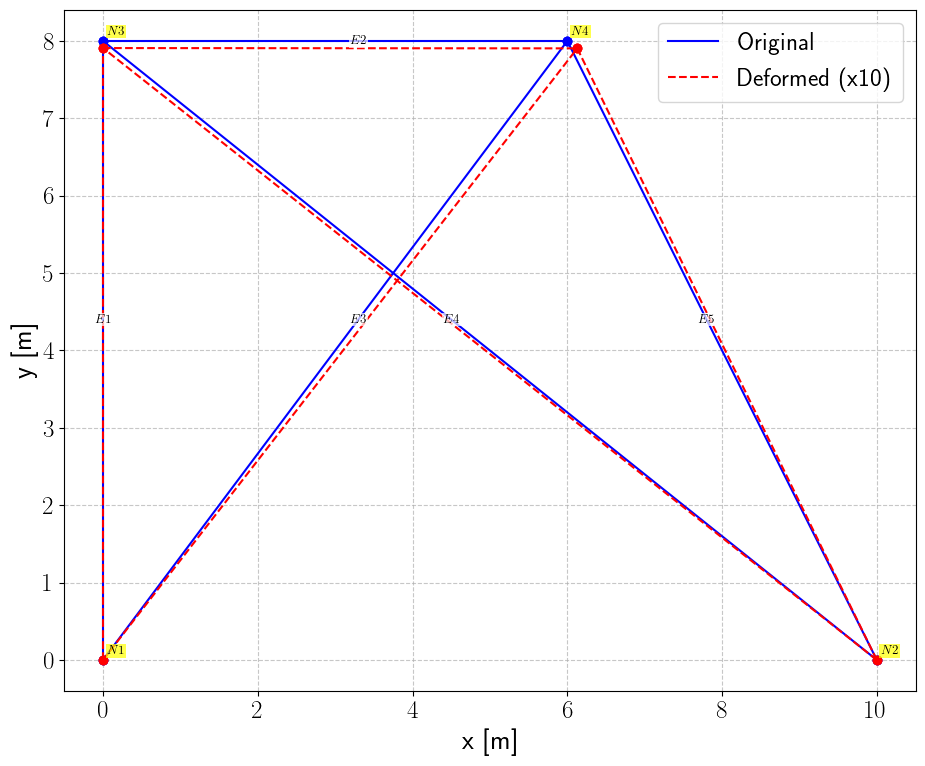

In [8]:
# Plot the obtained solution by amplifying the displacements

fig, ax = plt.subplots(figsize=(10, 8))
ax = plot_truss_structure_2d(coordinates, connectivity_table, ax=ax, 
        show_element_labels=True,
        show_node_labels=True,
        color='blue',
        linestyle='o-',
        label='Original',
        xlabel='x [m]',
        ylabel='y [m]',)

scale = 10
deformed_coordinates = coordinates + scale * q_all.reshape(-1, 2)
ax = plot_truss_structure_2d(deformed_coordinates, connectivity_table, ax=ax, color='red',
        linestyle='o--',
        show_element_labels=False,
        show_node_labels=False,
        label=f'Deformed (x{scale})')
plt.tight_layout()
plt.show()

Then we can reconstruct the displacements and reaction forces at each node and find the axial force in each element

In [9]:
from src.fem.compute_strains_forces import compute_strains_forces_truss_2d

f_all = K @ q_all

axial_strains, axial_forces = compute_strains_forces_truss_2d(coordinates, \
                                                    connectivity_table, q_all, EA)

for ii in range(n_elements):
    print(f"Axial force in element {ii+1}: \n {axial_forces[ii]:.3f} [MPa]")

Axial force in element 1: 
 -321.599 [MPa]
Axial force in element 2: 
 599.037 [MPa]
Axial force in element 3: 
 0.963 [MPa]
Axial force in element 4: 
 -125.502 [MPa]
Axial force in element 5: 
 -448.075 [MPa]


The axial forces depend on the physical parameters of each truss (structure is statically indetermined).
We can verify it by changing the parameters and compute the forces again

In [10]:
from scipy.sparse.linalg import norm

E_2 = 80 * 1e6 # kPa
A_2_vec = np.array([4000, 3000, 5000, 6000, 7000]) * 1e-6
EA_2 = A_2_vec * E_2

K_2 = assemble_stiffness_truss_2d(coordinates, connectivity_table, EA_2)

q_all_K2, reactions_K2 = solve_system_homogeneous_bcs(K_2, f, dofs_bcs)

print(f'Reactions for K2 [kN]: \n {reactions_K2}')
axial_strains_K2, axial_forces_K2 = compute_strains_forces_truss_2d(coordinates, \
                                                    connectivity_table, q_all_K2, EA_2)

for ii in range(n_elements):
    print(f"Difference local force in element {ii+1}: \n {axial_forces[ii] - axial_forces_K2[ii]:.1f} [kN]")


Reactions for K2 [kN]: 
 [ -82.30238595  183.1589079  -388.74897917  616.8410921  -328.94863488]
Difference local force in element 1: 
 -28.7 [kN]
Difference local force in element 2: 
 136.2 [kN]
Difference local force in element 3: 
 -136.2 [kN]
Difference local force in element 4: 
 45.9 [kN]
Difference local force in element 5: 
 121.8 [kN]


In [11]:
# Second load case 
dict_forces_2 = {4: np.array([1500, 0])}
f_2 = np.zeros(n_dofs)

for node, force_node in dict_forces_2.items():
    node_id = node - 1
    f_2[2*node_id:2*node_id+2] = force_node

q_all_f2, reactions_f2 = solve_system_homogeneous_bcs(K, f_2, dofs_bcs)

print(f"Displacement [mm]:\n {q_all_f2*1e3}\n")
print(f"Reactions at bcs in [kN]:\n {reactions_f2}\n")

f_all_f2 = K @ q_all_f2

axial_strains_f2, axial_forces_f2 = compute_strains_forces_truss_2d(coordinates, \
                                                connectivity_table, q_all_f2, EA)

for ii in range(n_elements):
    print(f"Local axial force element {ii+1}: \n {axial_forces_f2[ii]:.1f} [kN]")

Displacement [mm]:
 [ 0.          0.          0.          0.          0.          0.
 23.81404413 -0.50883932]

Reactions at bcs in [kN]:
 [ -233.2067644   -310.94235253  -155.47117627   310.94235253
 -1111.32205934]

Local axial force element 1: 
 0.0 [kN]
Local axial force element 2: 
 1111.3 [kN]
Local axial force element 3: 
 388.7 [kN]
Local axial force element 4: 
 0.0 [kN]
Local axial force element 5: 
 -347.6 [kN]


In order to find the optimal parameters to minimize mass and respect the safety requirements, we compute the area so that the stress is the maximum accetable.


In [12]:
sigma_max_MPa = 200 # [MPa]
safety_factor = 2

axial_sigma_kPa = E*axial_strains
axial_sigma_MPa = axial_sigma_kPa/1e3
print(f'Axial stress in [MPa]: \n {axial_sigma_MPa}')
sigma_max_security = sigma_max_MPa/2
sigma_ideal = sigma_max_security

A_opt = abs(axial_sigma_MPa)*A/sigma_ideal
assert np.isclose(abs(axial_sigma_kPa*A), abs(axial_forces)).all()
print(f'Ration cross section')
for ii in range(n_elements):
    print(f'Ratio element {ii+1}: {A_opt[ii]/A}')

Axial stress in [MPa]: 
 [ -80.39984883  149.75933023    0.24066977  -31.37555076 -112.01866046]
Ration cross section
Ratio element 1: 0.8039984882526215
Ratio element 2: 1.4975933023045926
Ratio element 3: 0.0024066976954077554
Ratio element 4: 0.3137555076107792
Ratio element 5: 1.1201866046091846


This is however not sufficient as the different areas will induce different internal stresses. We can verify this by computing again the stresses

In [13]:
EA_opt = E * A_opt
K_opt = assemble_stiffness_truss_2d(coordinates, connectivity_table, EA_opt)

q_all_opt, reactions_opt = solve_system_homogeneous_bcs(K_opt, f, dofs_bcs)

axial_strains_opt, axial_forces_opt = compute_strains_forces_truss_2d(coordinates, \
                                                connectivity_table, q_all_opt, EA_opt)

axial_stresses_opt_MPa = E*axial_strains_opt/1e3
for ii in range(n_elements):
    print(f"Local axial stress element {ii+1} in [MPa]: \n {axial_stresses_opt_MPa[ii]:.1f}")

Local axial stress element 1 in [MPa]: 
 -113.6
Local axial stress element 2 in [MPa]: 
 100.2
Local axial stress element 3 in [MPa]: 
 -19.7
Local axial stress element 4 in [MPa]: 
 -44.3
Local axial stress element 5 in [MPa]: 
 -99.8


As you can notice the value are not equal to $\sigma_{\mathrm{max}}/2$. This is due to the hyperstaticity of the structure. Forces and reactions depend on the physical parameters $(E, A, L)$ of the different trusses.

A feasible solution can be obtained via an iterative process, which can be either a constrained optimization algorithm, or an euristic reasoning that converges to an accetable solution.